# Building a Robust Preprocessing Pipeline with Missing Value Imputation, Outlier Detection, Memory Optimization, and Categorical Encoding

## Project 3

### Company:

Brainybeam Info-Tech Pvt Ltd

### Domain:

Data Science & Machine Learning

---

## Objective

The objective of this project is to build a complete preprocessing pipeline using the Titanic dataset. The pipeline focuses on improving data quality and preparing the dataset for machine learning models.

The preprocessing workflow includes:

* Handling missing values using:

  * Mean Imputation
  * Median Imputation
  * KNN Imputation

* Detecting and treating outliers using:

  * Z-Score Method
  * IQR Method

* Optimizing memory usage by:

  * Downcasting numerical data types
  * Converting object columns into category types

* Encoding categorical variables using:

  * One-Hot Encoding
  * Target Encoding

This project demonstrates how raw real-world data can be transformed into a clean and machine-learning-ready dataset.


In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Missing Value Imputation
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

# Outlier Detection
from scipy import stats

# Encoding
from sklearn.preprocessing import OneHotEncoder

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading the Titanic Dataset

 The Titanic dataset is a popular dataset used in data science and machine learning projects. It contains information about passengers such as age, sex, fare, class, and survival status. We will use Seaborn's built-in Titanic dataset.

In [9]:
# Load Titanic dataset

df = sns.load_dataset('titanic')

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
# Dataset shape

print("Rows and Columns:", df.shape)

Rows and Columns: (891, 15)


In [11]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [12]:
# Statistical summary

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Missing Value Analysis

Real-world datasets usually contain missing values.

We first identify which columns contain missing data.

In [14]:
# Check missing values

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


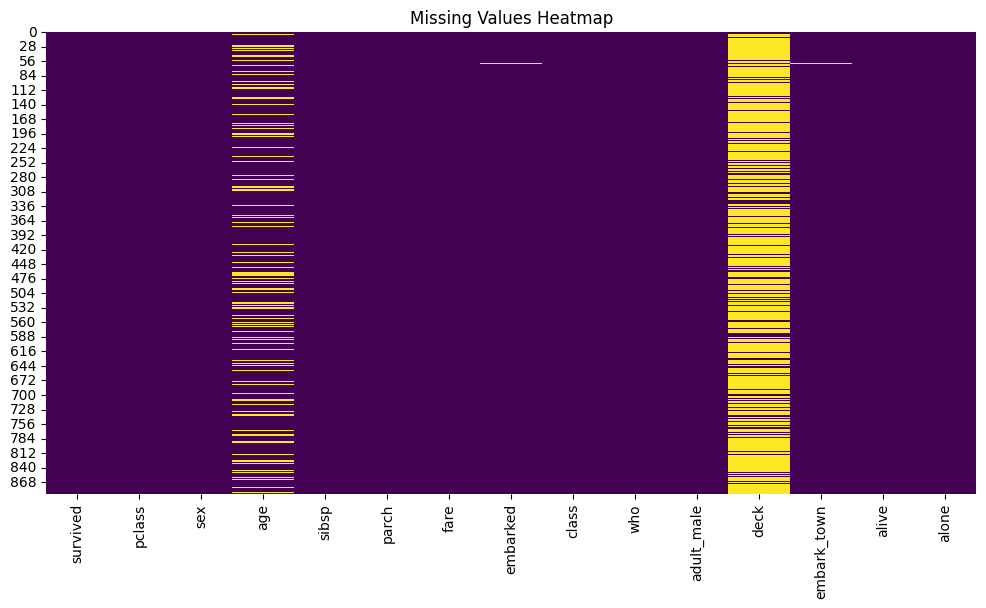

In [15]:
# Visualize missing values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cmap='viridis', cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

# Mean Imputation

Mean imputation replaces missing values with the average value of the column.

It works well for normally distributed numerical data.

In [16]:
# Copy dataset

mean_df = df.copy()

# Initialize mean imputer

mean_imputer = SimpleImputer(strategy='mean')

# Apply mean imputation on age column

mean_df['age'] = mean_imputer.fit_transform(mean_df[['age']])

# Verify missing values

mean_df['age'].isnull().sum()

np.int64(0)

# Median Imputation

Median imputation uses the median value instead of mean.

It is more effective when outliers are present.

In [17]:
# Copy dataset

median_df = df.copy()

# Median imputer

median_imputer = SimpleImputer(strategy='median')

# Apply median imputation

median_df['age'] = median_imputer.fit_transform(median_df[['age']])

# Check remaining missing values

median_df['age'].isnull().sum()

np.int64(0)

# KNN Imputation

KNN Imputation estimates missing values using neighboring observations.

This method often produces better results than simple statistical imputation.

In [18]:
# Copy dataset

knn_df = df.copy()

# Select numerical columns

numeric_cols = knn_df.select_dtypes(include=np.number)

# Initialize KNN imputer

knn_imputer = KNNImputer(n_neighbors=5)

# Fit and transform

knn_array = knn_imputer.fit_transform(numeric_cols)

# Convert into dataframe

knn_imputed_df = pd.DataFrame(
    knn_array,
    columns=numeric_cols.columns
)

# Display output

knn_imputed_df.head()

,survived,pclass,age,sibsp,parch,fare
0,0.0,3.0,22.0,1.0,0.0,7.2500
1,1.0,1.0,38.0,1.0,0.0,71.2833
2,1.0,3.0,26.0,0.0,0.0,7.9250
3,1.0,1.0,35.0,1.0,0.0,53.1000
4,0.0,3.0,35.0,0.0,0.0,8.0500


# Outlier Detection

Outliers are abnormal values that differ greatly from other data points.

We will use:
- Z-Score Method
- IQR Method

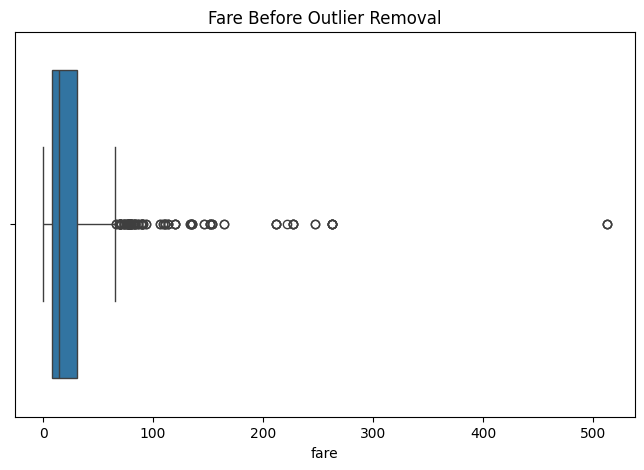

In [19]:
# Boxplot before removing outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=median_df['fare'])

plt.title("Fare Before Outlier Removal")

plt.show()

# Z-Score Method

Z-score indicates how many standard deviations a value is away from the mean.

Values greater than 3 are treated as outliers.

In [20]:
# Calculate z-score

z_scores = np.abs(stats.zscore(median_df['fare']))

# Detect outliers

z_outliers = median_df[z_scores > 3]

print("Total Outliers:", z_outliers.shape[0])

z_outliers.head()

Total Outliers: 20


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False
118,0,1,male,24.0,0,1,247.5208,C,First,man,True,B,Cherbourg,no,False
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
299,1,1,female,50.0,0,1,247.5208,C,First,woman,False,B,Cherbourg,yes,False


# IQR Method

IQR stands for Interquartile Range.

Formula:

IQR = Q3 - Q1

Outliers lie outside:
- Q1 - 1.5 × IQR
- Q3 + 1.5 × IQR

In [21]:
# Copy dataframe

iqr_df = median_df.copy()

# Calculate quartiles

Q1 = iqr_df['fare'].quantile(0.25)
Q3 = iqr_df['fare'].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Lower and upper limits

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Detect outliers

iqr_outliers = iqr_df[
    (iqr_df['fare'] < lower_limit) |
    (iqr_df['fare'] > upper_limit)
]

print("IQR Outliers:", iqr_outliers.shape[0])

IQR Outliers: 116


# Removing Outliers

Removing outliers helps improve model performance and data consistency.

In [22]:
# Remove outliers

clean_df = iqr_df[
    (iqr_df['fare'] >= lower_limit) &
    (iqr_df['fare'] <= upper_limit)
]

print("Original Shape:", iqr_df.shape)

print("New Shape:", clean_df.shape)

Original Shape: (891, 15)
New Shape: (775, 15)


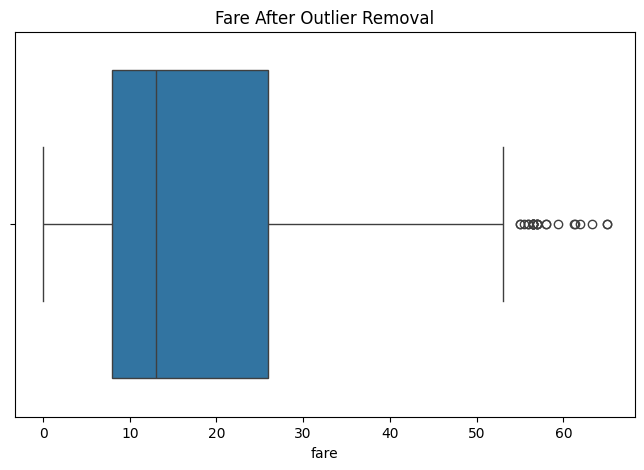

In [23]:
# Boxplot after removing outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=clean_df['fare'])

plt.title("Fare After Outlier Removal")

plt.show()

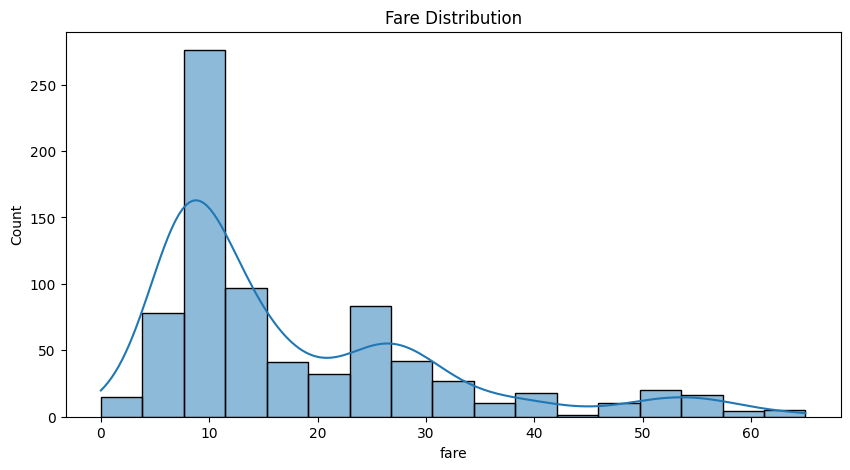

In [24]:
# Distribution plot

plt.figure(figsize=(10,5))

sns.histplot(clean_df['fare'], kde=True)

plt.title("Fare Distribution")

plt.show()

# Memory Optimization

Memory optimization improves:
- Speed
- Performance
- RAM efficiency

We will reduce memory usage using datatype conversion.

In [25]:
# Memory usage before optimization

print(clean_df.memory_usage(deep=True))

Index           6200
survived        6200
pclass          6200
sex            41563
age             6200
sibsp           6200
parch           6200
fare            6200
embarked       38750
class           1046
who            40862
adult_male       775
deck            1425
embark_town    46193
alive          39788
alone            775
dtype: int64


In [26]:
# Copy dataframe

optimized_df = clean_df.copy()

# Downcast float columns

optimized_df['fare'] = pd.to_numeric(
    optimized_df['fare'],
    downcast='float'
)

optimized_df['age'] = pd.to_numeric(
    optimized_df['age'],
    downcast='float'
)

# Convert object columns to category

object_cols = optimized_df.select_dtypes(include='object').columns

for col in object_cols:
    optimized_df[col] = optimized_df[col].astype('category')

print("Memory Optimization Completed")

Memory Optimization Completed


In [27]:
# Memory usage after optimization

print(optimized_df.memory_usage(deep=True))

Index          6200
survived       6200
pclass         6200
sex             991
age            3100
sibsp          6200
parch          6200
fare           3100
embarked       1033
class          1046
who            1043
adult_male      775
deck           1425
embark_town    1060
alive           986
alone           775
dtype: int64


# One-Hot Encoding

One-Hot Encoding converts categorical variables into binary columns.

In [28]:
# One-hot encoding

ohe_df = pd.get_dummies(
    optimized_df,
    columns=['sex', 'embarked'],
    drop_first=True
)

ohe_df.head()

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.250000,Third,man,True,NaN,Southampton,no,False,True,False,True
2,1,3,26.0,0,0,7.925000,Third,woman,False,NaN,Southampton,yes,True,False,False,True
3,1,1,35.0,1,0,53.099998,First,woman,False,C,Southampton,yes,False,False,False,True
4,0,3,35.0,0,0,8.050000,Third,man,True,NaN,Southampton,no,True,True,False,True
5,0,3,28.0,0,0,8.458300,Third,man,True,NaN,Queenstown,no,True,True,True,False


# Target Encoding

Target Encoding replaces categories using the average target value.

In [29]:
# Copy dataframe

target_df = optimized_df.copy()

# Calculate mean survival rate

target_mean = target_df.groupby('sex')['survived'].mean()

# Apply encoding

target_df['sex_encoded'] = target_df['sex'].map(target_mean)

target_df[['sex', 'sex_encoded']].head()

,sex,sex_encoded
0,male,0.178908
2,female,0.688525
3,female,0.688525
4,male,0.178908
5,male,0.178908


# Final Processed Dataset

The dataset is now:
- Cleaned
- Optimized
- Encoded
- Ready for Machine Learning

In [30]:
# Save dataset

ohe_df.to_csv("Titanic_Preprocessed.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


# Conclusion

In this project, we successfully built a complete preprocessing pipeline using the Titanic dataset.

The preprocessing workflow included:
- Missing value imputation
- Outlier detection and treatment
- Memory optimization
- Categorical encoding

These preprocessing steps are essential in real-world machine learning projects because clean and structured data improves model performance and reliability.